In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

sig = lambda z: 1.0 / (1.0 + np.exp(-z))

def logistic_prob(x, phi0, phi1):
    """Pr(y=1|x) = sig(phi0 + phi1 * x) for vector x."""
    return sig(phi0 + phi1 * x)

def cross_entropy_loss(x, y, phi0, phi1):
    z = phi0 + phi1 * x
    return np.sum(np.logaddexp(0.0, z) - y * z)

def cross_entropy_grads(x, y, phi0, phi1):
    z = phi0 + phi1 * x
    p = sig(z)
    diff = p - y
    dphi0 = np.sum(diff)
    dphi1 = np.sum(diff * x)
    return dphi0, dphi1

plt.rcParams.update({"figure.figsize": (5.5, 4), "axes.grid": True})

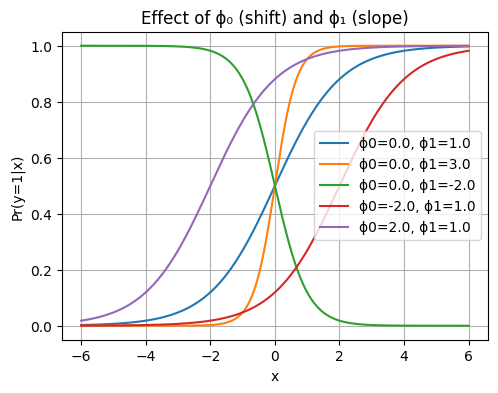

In [ ]:
x_grid = np.linspace(-6, 6, 400)
params = [
    (0.0, 1.0),
    (0.0, 3.0),
    (0.0, -2.0),
    (-2.0, 1.0),
    (2.0, 1.0),
]

fig, ax = plt.subplots()
for phi0, phi1 in params:
    ax.plot(x_grid, logistic_prob(x_grid, phi0, phi1), label=f"ϕ0={phi0}, ϕ1={phi1}")
ax.set_xlabel("x")
ax.set_ylabel("Pr(y=1|x)")
ax.set_title("Effect of ϕ₀ (shift) and ϕ₁ (slope)")
ax.legend(loc="best")
plt.show()

- ϕ₀ (bias/intercept) horizontally shifts the sigmoid along x. Increasing ϕ₀ moves the curve left (the 0.5-threshold occurs at x = -ϕ₀/ϕ₁ for ϕ₁ ≠ 0).
- ϕ₁ (slope) controls steepness and direction. Large |ϕ₁| makes the transition sharper. The sign of ϕ₁ determines whether probability increases or decreases with x.

- A standard choice is the negative log-likelihood (cross-entropy) for Bernoulli outcomes: L(ϕ) = −∑ᵢ [ yᵢ log pᵢ + (1−yᵢ) log(1−pᵢ) ], with pᵢ = sig(ϕ₀ + ϕ₁ xᵢ). This penalizes confident wrong predictions heavily and yields a convex objective in (ϕ₀, ϕ₁).

- Let zᵢ = ϕ₀ + ϕ₁ xᵢ and pᵢ = sig(zᵢ). Using d/dz log(1+eᶻ) = sig(z), we get: ∂L/∂ϕ₀ = ∑ᵢ (pᵢ − yᵢ) and ∂L/∂ϕ₁ = ∑ᵢ (pᵢ − yᵢ) xᵢ.

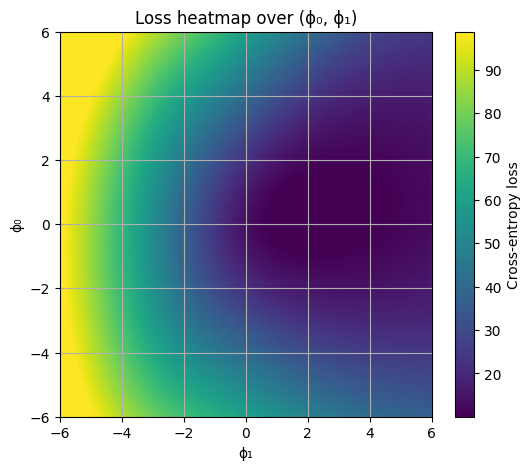

{'L(phi0=0,phi1=1)': np.float64(9.302787457755874), 'dphi0': np.float64(-0.7285107350498653), 'dphi1': np.float64(-2.2785478701805904)}


In [ ]:
rng = np.random.default_rng(0)

x0 = rng.normal(loc=-1.0, scale=1.0, size=10)
y0 = np.zeros_like(x0)

x1 = rng.normal(loc=1.0, scale=1.0, size=10)
y1 = np.ones_like(x1)

x = np.concatenate([x0, x1])
y = np.concatenate([y0, y1])

phi0_grid = np.linspace(-6, 6, 121)
phi1_grid = np.linspace(-6, 6, 121)
loss_grid = np.zeros((len(phi0_grid), len(phi1_grid)))

for i, phi0 in enumerate(phi0_grid):
    for j, phi1 in enumerate(phi1_grid):
        loss_grid[i, j] = cross_entropy_loss(x, y, phi0, phi1)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    loss_grid,
    origin="lower",
    extent=[phi1_grid.min(), phi1_grid.max(), phi0_grid.min(), phi0_grid.max()],
    aspect="auto",
    cmap="viridis",
    norm=Normalize(vmin=np.percentile(loss_grid, 5), vmax=np.percentile(loss_grid, 95))
)
cb = plt.colorbar(im, ax=ax)
cb.set_label("Cross-entropy loss")
ax.set_xlabel("ϕ₁")
ax.set_ylabel("ϕ₀")
ax.set_title("Loss heatmap over (ϕ₀, ϕ₁)")
plt.show()

phi0_test, phi1_test = 0.0, 1.0
L_test = cross_entropy_loss(x, y, phi0_test, phi1_test)
dphi0, dphi1 = cross_entropy_grads(x, y, phi0_test, phi1_test)
print({"L(phi0=0,phi1=1)": L_test, "dphi0": dphi0, "dphi1": dphi1})

For logistic regression with Bernoulli likelihood, the negative log-likelihood is a sum of terms of the form

ℓ(z) = log(1 + e^z) − y z, with z = ϕ₀ + ϕ₁ x.

- The function log(1 + e^z) is convex in z (its second derivative is sig(z)(1 − sig(z)) ≥ 0).
- Affine composition preserves convexity: z is affine in (ϕ₀, ϕ₁).
- A nonnegative weighted sum of convex functions is convex; here it is simply a sum over i.

Therefore L(ϕ) is convex in (ϕ₀, ϕ₁).